# Student Health vs. Social Media and AI Usage: EDA

Exploratory analysis of 16,000 students: how are daily social media and AI tool usage related to sleep, activity, and mental and physical health?


#### importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('AI_SocialMedia_Student_Dataset.csv')

In [4]:
df.head()

,Student_ID,Age,Gender,Education_Level,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score
0,STU_00001,19,Male,College,5.32,1.21,7.30,1.41,74.06,98.90
1,STU_00002,16,Non-binary,High School,5.21,3.89,7.81,2.48,76.13,89.94
2,STU_00003,25,Male,University,3.61,2.65,6.34,0.06,65.01,76.75
3,STU_00004,23,Male,University,2.93,1.43,6.12,1.37,74.67,87.38
4,STU_00005,20,Non-binary,College,6.52,1.64,5.23,1.14,67.74,88.04


### Looking into the data


In [6]:
df.shape

(16000, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Student_ID                 16000 non-null  object 
 1   Age                        16000 non-null  int64  
 2   Gender                     16000 non-null  object 
 3   Education_Level            16000 non-null  object 
 4   Daily_Social_Media_Hours   16000 non-null  float64
 5   Daily_AI_Tool_Usage_Hours  16000 non-null  float64
 6   Sleep_Hours                16000 non-null  float64
 7   Physical_Activity_Hours    16000 non-null  float64
 8   Mental_Health_Score        16000 non-null  float64
 9   Physical_Health_Score      16000 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 1.2+ MB


In [8]:
df.isnull().sum()

Student_ID                   0
Age                          0
Gender                       0
Education_Level              0
Daily_Social_Media_Hours     0
Daily_AI_Tool_Usage_Hours    0
Sleep_Hours                  0
Physical_Activity_Hours      0
Mental_Health_Score          0
Physical_Health_Score        0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.nunique()

Student_ID                   16000
Age                             13
Gender                           3
Education_Level                  3
Daily_Social_Media_Hours      1106
Daily_AI_Tool_Usage_Hours      762
Sleep_Hours                    752
Physical_Activity_Hours        462
Mental_Health_Score           3743
Physical_Health_Score         3433
dtype: int64

### Summary statistics

In [12]:
df.describe()

,Age,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score
count,16000.00000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,19.03875,4.541791,2.590624,6.545371,1.248359,72.493193,88.020465
std,3.76527,2.403044,1.679376,1.270515,1.038632,9.244818,9.691037
min,13.00000,0.000000,0.000000,2.000000,0.000000,32.560000,48.030000
25%,16.00000,2.840000,1.310000,5.680000,0.310000,66.760000,81.517500
50%,19.00000,4.500000,2.520000,6.540000,1.130000,73.750000,89.455000
75%,22.00000,6.180000,3.750000,7.410000,1.960000,79.550000,97.170000
max,25.00000,14.000000,9.500000,11.150000,5.000000,91.760000,99.980000


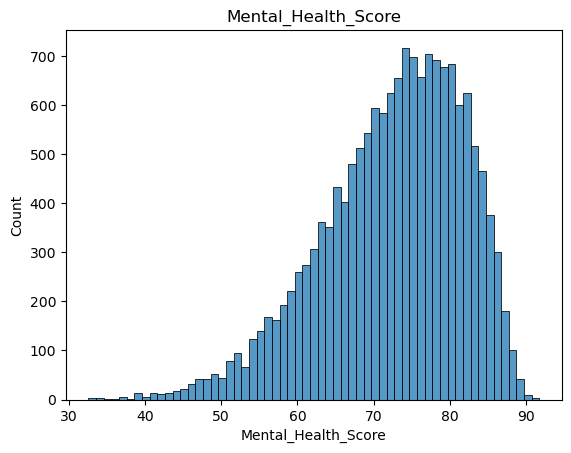

In [13]:
sns.histplot(df['Mental_Health_Score'])
plt.title('Mental_Health_Score')
plt.show()

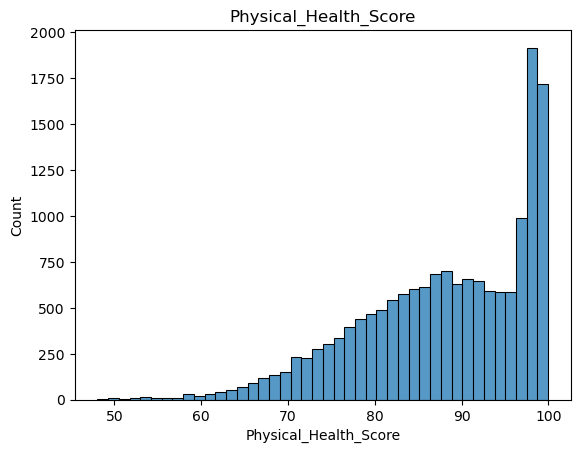

In [14]:
sns.histplot(df['Physical_Health_Score'])
plt.title('Physical_Health_Score')
plt.show()

In [15]:
df.value_counts('Gender')

Gender
Male          7744
Female        7628
Non-binary     628
Name: count, dtype: int64

In [16]:
df.value_counts('Education_Level')

Education_Level
High School    6083
University     5027
College        4890
Name: count, dtype: int64

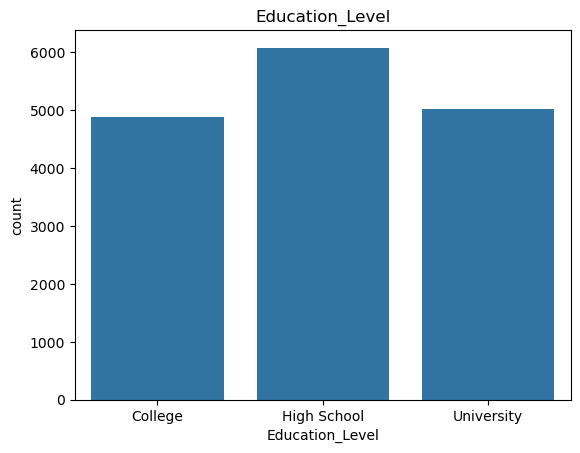

In [17]:
sns.countplot(x='Education_Level', data=df)
plt.title('Education_Level')
plt.show()

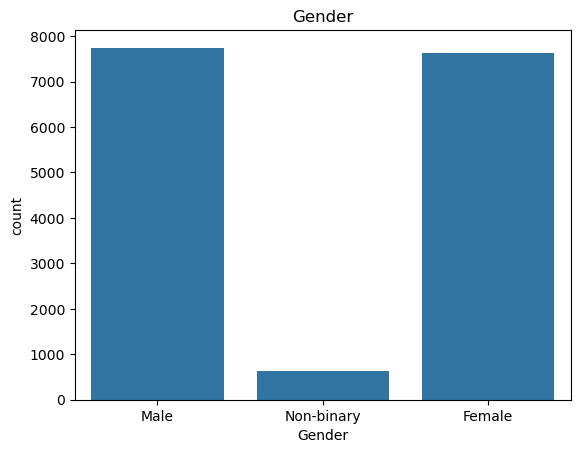

In [18]:
sns.countplot(x='Gender', data=df)
plt.title('Gender')
plt.show()

In [19]:

df['Physical_Health_Score']>=99

0        False
1        False
2        False
3        False
4        False
         ...  
15995    False
15996    False
15997     True
15998    False
15999    False
Name: Physical_Health_Score, Length: 16000, dtype: bool

In [20]:
(df['Physical_Health_Score']>=99).sum()

1330

In [21]:
(df['Physical_Health_Score']>=99).mean()*100

8.3125


About 8% of students have a Physical_Health_Score of 99 or higher, so the score is capped near 100.

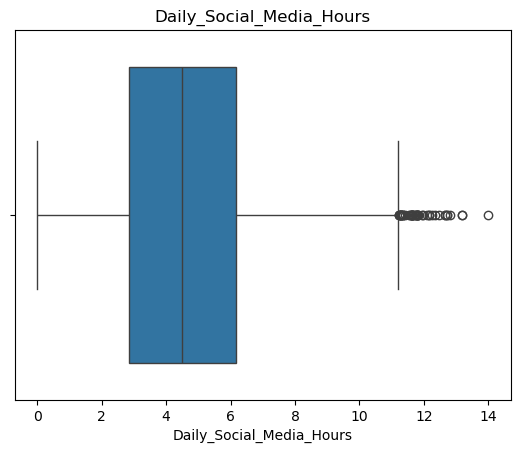

In [23]:
import seaborn as sns
sns.boxplot(x= df['Daily_Social_Media_Hours'])
plt.title('Daily_Social_Media_Hours')
plt.show()

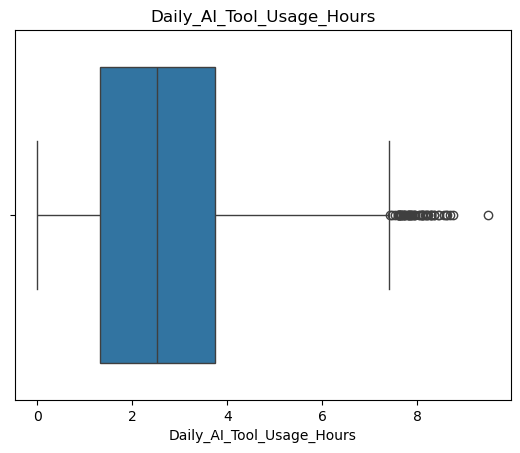

In [24]:
sns.boxplot(x=df['Daily_AI_Tool_Usage_Hours']);
plt.title('Daily_AI_Tool_Usage_Hours')
plt.show()

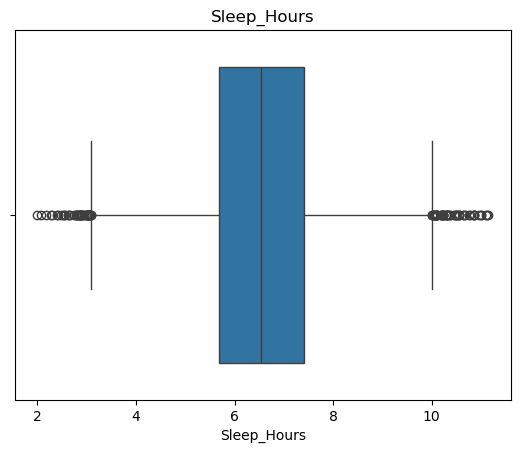

In [25]:
sns.boxplot(x=df['Sleep_Hours']);
plt.title('Sleep_Hours')
plt.show()


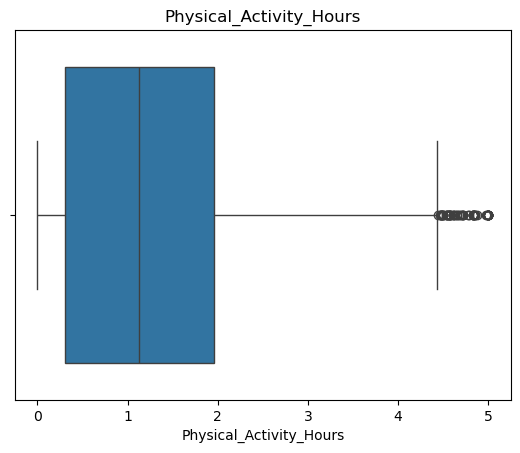

In [26]:
sns.boxplot(x=df['Physical_Activity_Hours'])
plt.title('Physical_Activity_Hours')
plt.show()

In [27]:
col = 'Daily_Social_Media_Hours'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

-2.17 11.19


In [28]:
low_count = (df[col] < lower).sum()
high_count = (df[col] > upper).sum()

print("Low outliers:", low_count)
print("High outliers:", high_count)

Low outliers: 0
High outliers: 49


 49 students (0.3%) use social media more than 11.2 hours a day. These are plausible heavy users, not data errors, so I kept them.

In [30]:
df.groupby('Gender')[['Mental_Health_Score', 'Physical_Health_Score']].mean()

,Mental_Health_Score,Physical_Health_Score
Gender,,
Female,72.535110,87.936658
Male,72.481782,88.130382
Non-binary,72.124761,87.683010


In [31]:
df.groupby('Education_Level')[['Mental_Health_Score', 'Physical_Health_Score']].mean()

,Mental_Health_Score,Physical_Health_Score
Education_Level,,
College,72.677274,88.161857
High School,72.344550,87.930950
University,72.493996,87.991245


In [32]:
df.corr(numeric_only=True)

,Age,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score
Age,1.000000,-0.002394,0.012884,-0.004898,0.003846,0.005329,0.003077
Daily_Social_Media_Hours,-0.002394,1.000000,0.003032,-0.297566,-0.156614,-0.403584,-0.308048
Daily_AI_Tool_Usage_Hours,0.012884,0.003032,1.000000,-0.140798,0.013161,-0.110701,-0.022809
Sleep_Hours,-0.004898,-0.297566,-0.140798,1.000000,0.042490,0.312832,0.269694
Physical_Activity_Hours,0.003846,-0.156614,0.013161,0.042490,1.000000,0.245338,0.420732
Mental_Health_Score,0.005329,-0.403584,-0.110701,0.312832,0.245338,1.000000,0.246062
Physical_Health_Score,0.003077,-0.308048,-0.022809,0.269694,0.420732,0.246062,1.000000


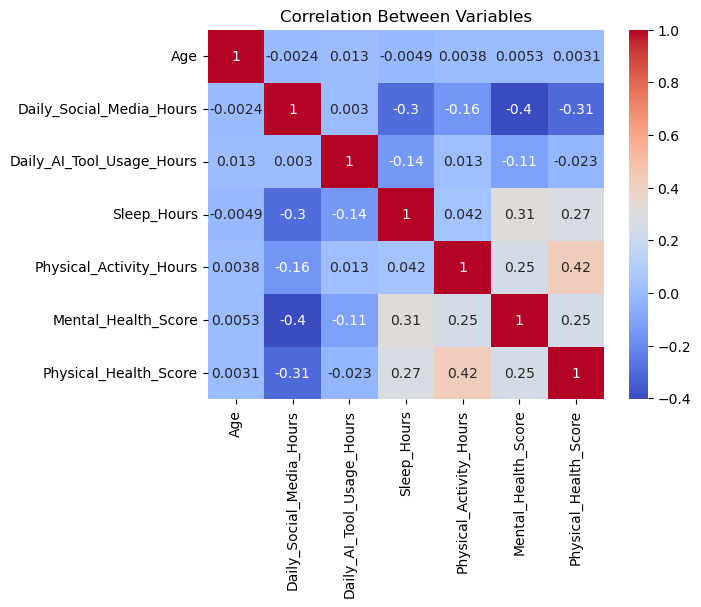

In [33]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm');
plt.title('Correlation Between Variables')
plt.show()



In [34]:
df['SM_Level'] = pd.cut(df['Daily_Social_Media_Hours'], bins=[0, 3, 6, 15],
                        labels=['Low', 'Medium', 'High'], include_lowest=True)
df.groupby('SM_Level', observed=False)['Mental_Health_Score'].mean()

SM_Level
Low       76.792682
Medium    72.775939
High      67.725255
Name: Mental_Health_Score, dtype: float64

 Students who use social media more than 6 hours a day have an average mental health score of 67.7, about 9 points lower than students who use it less than 3 hours a day (76.8)

## Findings

- Social media is associated with lower mental health (-0.40). Heavy users (over 6 hours a day) score about 9 points lower than light users.
- AI usage has a much weaker link to health than social media.
- Physical activity has the strongest link to physical health (+0.42).
- Gender and education level make almost no difference to health scores.

## Limitations

- Correlation isn't causation.
- Physical_Health_Score is capped near 100.
- The data may be simulated, because age relates to nothing.